In [2]:
import glob
import h5py
import importlib
import IPython.display as ipd
import numpy as np
import os
import sys
from pathlib import Path
import pickle

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


# Pick stimuli for selectivity influence and model interpretability analysis

## Main question of this analysis: How does the model use voice and location features to solve the word task?

### Proposed approach: Measure how gains for input features influence unit activity for units that are selective for target words

#### In brief: 
* Want to compute "average" gains for specific voices and locations
    * e.g. for feature_x gains, get average gains from N examples of feature_x
* Compute delta in activity for each set of gains (e.g. talker a gains, talker b gains, ...., 10 degree azimuth gains) 
* Compute average of deltas for each category to get average influence of location and voice 
* Main results graph will be average delta in activity by unit, with units sorted by their initial selectivity for target words 

We are interested in how attending to specific features of input stimuli influences network activity. 
We have seen that units in the network show some tuning for f0 of voice and location. We now want to know how those features influence the activity of units that are selective for the target words.  

Relative selectivity to target words is what we are most interested in - not selectivity for specific words themselves. 

To determine word selectivity, we can use a target and distractor speech signal. Using activations of the target talker alone $z_t^{(\mathcal{l})} = f(x_t; \theta)$ and distractor talker alone $z_d^{(\mathcal{l})} = f(x_d; \theta)$ from a given network layer $l$, we can calculate a selectivity index for a target as $s_i = \log(z_{ti}^{(l)}) - \log(z_{di}^{(l)})$, the log ratio of target activity, $z_{ti}^{(l)}$, to distractor activity, $z_{di}^{(l)}$, for the i-th unit of a layer $l$.  

To measure how stimulus features influence unit activations, we measure how gains for those features affect activations. First, we compute the average gains for a specific feature $v$ (e.g. 10 degrees azimuth). For each $v$, we can compute the average gain for that feature as $ \bar{g}_v^{(\mathcal{l})} = \mathbb{E}_{v}[g^{(\mathcal{l})}]$, where gains are $g^{(\mathcal{l})} = \sigma(z_c^{(\mathcal{l})}, \theta)$, a function of the cue activations $z_c^{(\mathcal{l})} = f(x_c; \theta)$. We can then get the modulated acitvations for the target and distractor by applying the gains their activations, i.e. $ q_{.i}^{(l)} = z_{.i}^{(l)} \times \bar{g}_{vi}^{(\mathcal{l})}$. We can then plot $q_{.i}^{(l)}$, looking at the effect of specific features $v$ (i.e. 10 azim) 




## Import saved activations for proof of concept  


Need to run this with independent cues, targets and distractors, where target and distractors are passed through the model without attention 

In [3]:
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
# print(h5.keys())
# for key in h5.keys():
#     print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

In [29]:
np.random.seed(10)
### Pick layer 
layer_ix = 1 # has 640 units, so manageable for notebook

# pick a target as example 
target_azim = 90 
target_ix = np.random.choice(np.argwhere(target_locs[:,0] == target_azim).flatten()).astype('int')

target_f0 = target_f0s[target_ix]
target_loc = target_locs[target_ix]
print(f"Target f0: {target_f0:.2f}, Target loc: {target_loc}")

# pick a distractor for an example at opposite location
distractor_ix = np.random.choice(np.argwhere(target_locs[:,0] == 270).flatten()).astype('int')
distractor_f0 = target_f0s[distractor_ix]
distractor_loc = target_locs[distractor_ix]
print(f"Distractor f0: {distractor_f0:.2f}, Distractor loc: {distractor_loc}")

# gain ix is layer_ix + 1
gains = h5[f"attn{layer_ix+1}_gains"][:]

target_features = h5[f"hann_pool_{layer_ix}_cue"][target_ix,:]
distractor_features = h5[f"hann_pool_{layer_ix}_cue"][distractor_ix,:]

Target f0: 134.23, Target loc: [90.  0.]
Distractor f0: 190.43, Distractor loc: [270.   0.]


(640,)

/tmp/ipykernel_101409/3961433386.py:5: RuntimeWarning: divide by zero encountered in log
  ratios = np.log(target) - np.log(distractor)
/tmp/ipykernel_101409/3961433386.py:5: RuntimeWarning: invalid value encountered in subtract
  ratios = np.log(target) - np.log(distractor)


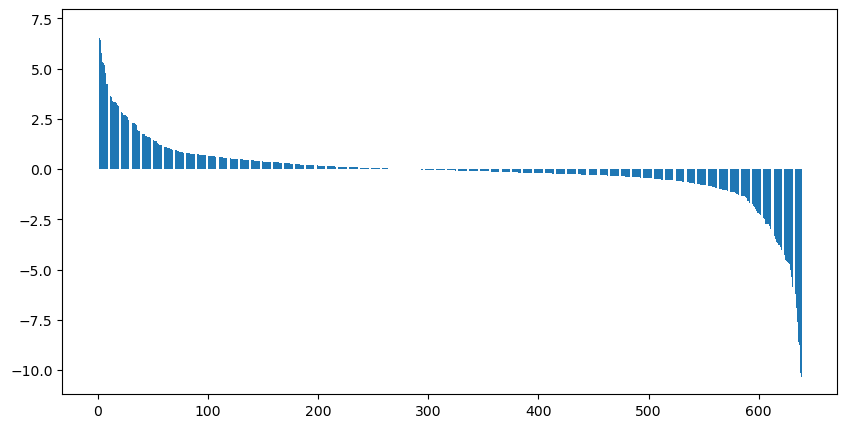

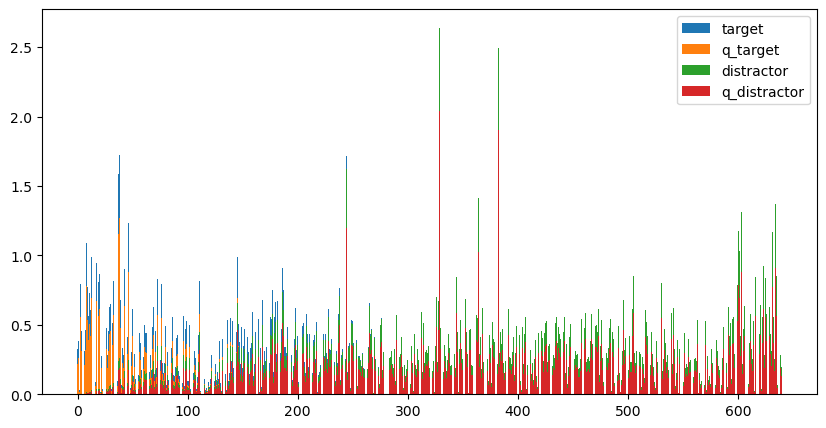

In [30]:
# get act selectivity ratio 

def unit_act_ratio(target, distractor):
    """Get log ratio of target and distractor activations per unit"""
    ratios = np.log(target) - np.log(distractor)
    # set nans and infs to 0 - dead units stay 0 this way 
    ratios = np.nan_to_num(ratios, nan=0, posinf=0, neginf=0)
    return ratios

unit_act_ratios = unit_act_ratio(target_features, distractor_features)
# rank units by selectivity
unit_rank = np.argsort(unit_act_ratios)[::-1]

plt.figure(figsize=(10,5))
plt.bar(np.arange(len(unit_rank)), unit_act_ratios[unit_rank])
# get gains for specific feature 

loc_feature_mask = np.argwhere(target_locs[:,0] == target_azim).flatten()
avg_feature_gains = gains[loc_feature_mask,:].mean(axis=0)

# apply gains to target_features
q_feats = avg_feature_gains * target_features
q_feats_distractor = avg_feature_gains * distractor_features

# activity_delta = q_feats - target_features 
# act_delta_distractor = q_feats_distractor - distractor_features
# plot act delta, ranking units by selectivity 

plt.figure(figsize=(10,5))
plt.bar(np.arange(len(unit_rank)), target_features[unit_rank], label='target')
plt.bar(np.arange(len(unit_rank)), q_feats[unit_rank], label='q_target')
plt.bar(np.arange(len(unit_rank)), distractor_features[unit_rank], label='distractor')
plt.bar(np.arange(len(unit_rank)), q_feats_distractor[unit_rank], label='q_distractor')


plt.legend();


In [31]:
q_selectivity = unit_act_ratio(q_feats, q_feats_distractor)


/tmp/ipykernel_101409/3961433386.py:5: RuntimeWarning: divide by zero encountered in log
  ratios = np.log(target) - np.log(distractor)
/tmp/ipykernel_101409/3961433386.py:5: RuntimeWarning: invalid value encountered in subtract
  ratios = np.log(target) - np.log(distractor)


In [32]:
unit_act_ratios[unit_act_ratios > 0 ].shape[0] / unit_act_ratios.shape[0]

0.4359375

In [33]:
q_selectivity[q_selectivity > 0 ].shape[0] / q_selectivity.shape[0]

0.4359375